<a href="https://colab.research.google.com/github/kestrel677/Supervised-Machine-learning-/blob/main/linear_Regreesion8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **House price prediction model:**

**DATA LOADING:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("/content/house_prices_dataset.csv")
df.head()
#In this data the age column means number of years since the house was built.

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


In [ ]:
df.shape

(10000, 5)

In [ ]:
df.dtypes

,0
square_feet,float64
num_rooms,int64
age,int64
distance_to_city(km),float64
price,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [ ]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1999.147496,4.49510,49.516900,15.362148,263011.571609
std,501.021194,1.71116,28.992336,8.325101,98336.945117
min,500.000000,2.00000,0.000000,1.000161,-95613.138249
25%,1663.704735,3.00000,24.000000,8.121636,196791.510684
50%,1998.702512,4.00000,49.000000,15.403146,262497.361236
75%,2335.540444,6.00000,75.000000,22.447530,330445.581908
max,3963.118853,7.00000,99.000000,29.993892,660168.255648


# **DATA CLEANING:**

In [ ]:
df.isnull().sum()

,0
square_feet,0
num_rooms,0
age,0
distance_to_city(km),0
price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# there is No null andd duplicate value in it

In [ ]:
#ckecking outliers
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

square_feet: 83 outliers
num_rooms: 0 outliers
age: 0 outliers
distance_to_city(km): 0 outliers
price: 64 outliers


In [ ]:
#Remove outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

square_feet: 0 outliers
num_rooms: 0 outliers
age: 0 outliers
distance_to_city(km): 0 outliers
price: 0 outliers


In [ ]:
#ckeck skewness
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].skew()

,0
square_feet,0.003016
num_rooms,0.007929
age,0.001240
distance_to_city(km),0.016093
price,0.001116


**DATA VISUALIZATION:**

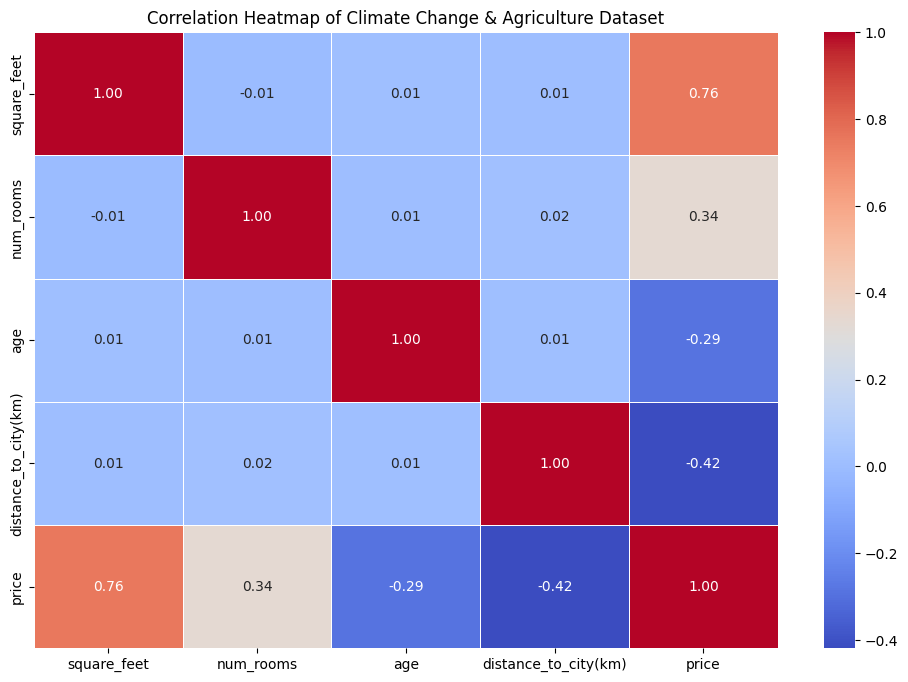

In [ ]:
#Using  heatmap in data visulization to find relationship between all numerical variables with eachother.
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Climate Change & Agriculture Dataset")
plt.show()

insights: there is no relationship here,and has negative relation

# **Feature Engineering:** There is no need of feature engineering in this data set

 # **Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Model Training

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Model Prediction

In [ ]:
y_pred = model.predict(X_test)

#Model Evaluation

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9596446254738742
MAE: 15613.235924524308


In [ ]:
#cheak how many percentage error is there.
mae = 15613
mean_price = y_test.mean()

print("MAE %:", (mae / mean_price) * 100)

MAE %: 5.979936190251147


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))

R2 Score: 0.9596446271114519
MAE: 15613.231541870851


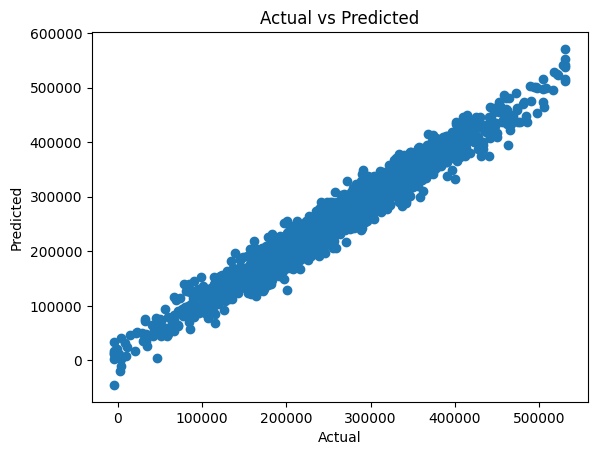

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))

R2 Score: 0.9596445882084225
MAE: 15613.221412234581


In [ ]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha = 0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_elastic))
print("MAE:", mean_absolute_error(y_test, y_pred_elastic))

R2 Score: 0.9572637870841986
MAE: 16068.890541372504


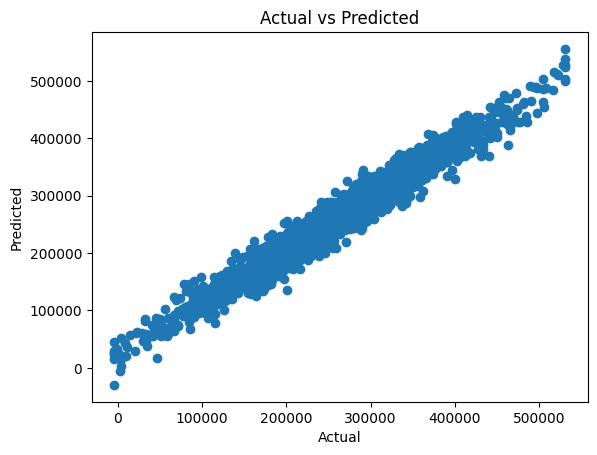

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_elastic)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.9572178090784338
Test Score: 0.9596446254738742
